# Imports necessários

## Bibliotecas

In [1]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

import statistics as st
import sys
import math
import pandas as pd
import numpy as np
sys.path.insert(1, '..\Modelo')


## Importando a série

In [2]:
df = pd.read_csv("../Dados/Dados refinados/timeseries.csv", index_col= 0)
df.head(10)

,mes,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,QTD_VEICULOS_USINA,primeira_quinzena,feriado,fim_semana,lag_1h,lag_1d,lag_7d,TPV
0,1,9.659258e-01,-0.258819,-0.974928,-0.222521,21,1,0,1,8.840000,6.538125,2.220000,8.484063
1,1,8.660254e-01,-0.500000,-0.974928,-0.222521,23,1,0,1,8.885333,6.293235,2.220000,8.150294
2,1,8.660254e-01,-0.500000,-0.974928,-0.222521,28,1,0,1,8.484063,6.093056,2.476667,7.830648
3,1,7.071068e-01,-0.707107,-0.974928,-0.222521,35,1,0,1,8.150294,5.945197,2.605000,7.581667
4,1,7.071068e-01,-0.707107,-0.974928,-0.222521,32,1,0,1,7.830648,5.780604,2.682000,7.362583
5,1,5.000000e-01,-0.866025,-0.974928,-0.222521,29,1,0,1,7.581667,5.620099,2.733333,7.186905
6,1,5.000000e-01,-0.866025,-0.974928,-0.222521,29,1,0,1,7.362583,5.523352,2.770000,6.978712
7,1,2.588190e-01,-0.965926,-0.974928,-0.222521,30,1,0,1,7.186905,5.412337,2.797500,6.898043
8,1,2.588190e-01,-0.965926,-0.974928,-0.222521,32,1,0,1,6.978712,5.309656,2.818889,6.772153
9,1,1.224647e-16,-1.000000,-0.974928,-0.222521,31,1,0,1,6.898043,5.209537,2.808000,6.632307


# Transformação de dados

## Normalizando os dados

In [42]:
#Separando X e y

X = df.iloc[:, :-1]
y = df.iloc[:,-1]

In [43]:
#Definindo o scalers
scaler_X, scaler_y = MinMaxScaler(),MinMaxScaler()

#fit
# scaler_X.fit(X[['mes','QTD_VEICULOS_USINA']])
scaler_X.fit(X)
scaler_y.fit(pd.DataFrame(y))

#transform

# X[['mes','QTD_VEICULOS_USINA']] = scaler_X.transform(X[['mes','QTD_VEICULOS_USINA']])
X = pd.DataFrame(scaler_X.transform(X), columns= X.columns)
y = scaler_y.transform(pd.DataFrame(y))

In [19]:
cat_cols = ['mes', 'primeira_quinzena', 'feriado', 'fim_semana']

for col in cat_cols:
    X[col] = X[col].astype('category')

# Cross-validation (Timeseries)

In [5]:
ts_cv = TimeSeriesSplit(n_splits=5)
all_splits = list(ts_cv.split(X, y))

In [6]:
all_splits

[(array([   0,    1,    2, ..., 1713, 1714, 1715]),
  array([1716, 1717, 1718, ..., 3424, 3425, 3426])),
 (array([   0,    1,    2, ..., 3424, 3425, 3426]),
  array([3427, 3428, 3429, ..., 5135, 5136, 5137])),
 (array([   0,    1,    2, ..., 5135, 5136, 5137]),
  array([5138, 5139, 5140, ..., 6846, 6847, 6848])),
 (array([   0,    1,    2, ..., 6846, 6847, 6848]),
  array([6849, 6850, 6851, ..., 8557, 8558, 8559])),
 (array([   0,    1,    2, ..., 8557, 8558, 8559]),
  array([ 8560,  8561,  8562, ..., 10268, 10269, 10270]))]

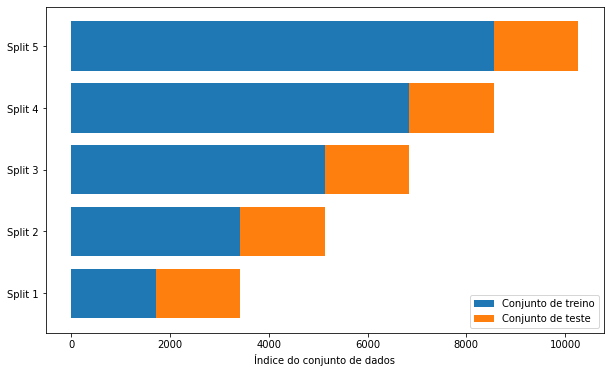

In [29]:
import matplotlib.pyplot as plt

# Dados fornecidos
splits = [
    (list(range(0, 1716)), list(range(1716, 3427))),
    (list(range(0, 3427)), list(range(3427, 5138))),
    (list(range(0, 5138)), list(range(5138, 6849))),
    (list(range(0, 6849)), list(range(6849, 8560))),
    (list(range(0, 8560)), list(range(8560, 10271)))
]

# Configurações do gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Itera pelos splits e plota as barras
for i, (train_idx, test_idx) in enumerate(splits):
    ax.broken_barh([(min(train_idx), len(train_idx))], (i - 0.4, 0.8), facecolors='tab:blue', label='Conjunto de treino' if i == 0 else "")
    ax.broken_barh([(min(test_idx), len(test_idx))], (i - 0.4, 0.8), facecolors='tab:orange', label='Conjunto de teste' if i == 0 else "")

# Configurações dos eixos
ax.set_yticks(range(len(splits)))
ax.set_yticklabels([f"Split {i+1}" for i in range(len(splits))])
ax.set_xlabel("Índice do conjunto de dados")
ax.legend(loc='lower right')

# Mostra o gráfico
plt.show()


# Modelagem


## KNN


In [31]:
from sklearn.neighbors import KNeighborsRegressor

def avaliaModelo_KNN(X, y, splits = all_splits):

    param = {'n_neighbors': 5}
    print("Cross-validation - KNN")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        model = KNeighborsRegressor(**param)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(predictions.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )


In [32]:
avaliaModelo_KNN(X.values, y, splits = all_splits)

Cross-validation - KNN
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 1.235243589317856 | RMSE: 1.7114583865575304


[2/5] X_train: (3427, 12), y_train: (3427, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 1.1132039388762351 | RMSE: 1.4219624716960952


[3/5] X_train: (5138, 12), y_train: (5138, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 1.3853818496339863 | RMSE: 1.9348956643055062


[4/5] X_train: (6849, 12), y_train: (6849, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 2.176815684845451 | RMSE: 4.4383184461365


[5/5] X_train: (8560, 12), y_train: (8560, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 2.8003066334076743 | RMSE: 3.7707366172422616


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 1.742 +/- 0.646
RMSE: 2.655 +/- 1.213


## Arvores de regressao

In [33]:
from sklearn.tree import DecisionTreeRegressor

def avaliaModelo_Arv_reg(X, y, splits = all_splits):

    param = {'max_depth': 6}
    print("Cross-validation - Arv_reg")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        model = DecisionTreeRegressor(**param)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(predictions.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )


In [35]:
avaliaModelo_Arv_reg(X.values, y, splits = all_splits)

Cross-validation - Arv_reg
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.42353647203316175 | RMSE: 0.8580440528119609


[2/5] X_train: (3427, 12), y_train: (3427, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.29720570667847146 | RMSE: 0.5508712604516831


[3/5] X_train: (5138, 12), y_train: (5138, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.32493026951198095 | RMSE: 0.6849086762849899


[4/5] X_train: (6849, 12), y_train: (6849, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.628413578484338 | RMSE: 2.6991131892351286


[5/5] X_train: (8560, 12), y_train: (8560, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.2124181252684064 | RMSE: 0.44856280648642577


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 0.377 +/- 0.143
RMSE: 1.048 +/- 0.837


## LGBM

In [36]:
from lightgbm import LGBMRegressor

def avaliaModelo_LGBM(X, y, splits = all_splits):

    param = {'max_depth': 6}
    print("Cross-validation - Arv_reg")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        model = DecisionTreeRegressor(**param)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(predictions.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )

In [37]:
avaliaModelo_LGBM(X.values, y, splits = all_splits)

Cross-validation - Arv_reg
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.4136742393936724 | RMSE: 0.8454935568011513


[2/5] X_train: (3427, 12), y_train: (3427, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.2992396049835562 | RMSE: 0.5572220685931412


[3/5] X_train: (5138, 12), y_train: (5138, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.3458685723847336 | RMSE: 0.7987274551721594


[4/5] X_train: (6849, 12), y_train: (6849, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.6001110035683587 | RMSE: 2.529858711149062


[5/5] X_train: (8560, 12), y_train: (8560, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.21241812526840634 | RMSE: 0.4485628064864257


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 0.374 +/- 0.131
RMSE: 1.036 +/- 0.761


## Gradient Boosting Model

In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor

gbrt = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=42)
categorical_columns = X.columns[X.dtypes == "category"]
print("Categorical features:", categorical_columns.tolist())

Categorical features: ['mes', 'primeira_quinzena', 'feriado', 'fim_semana']


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def avaliaModelo_GBR(X, y, splits = all_splits):

    print("Cross-validation - GBR")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        model = GradientBoostingRegressor(learning_rate= 0.1, n_estimators= 64)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(predictions.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )


In [11]:
avaliaModelo_GBR(X.values, y.ravel(), splits = all_splits)

Cross-validation - GBR
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716,), X_test: (1711, 12), y_test: (1711,)
MAE: 0.3417161010994555 | RMSE: 0.6329238043851046


[2/5] X_train: (3427, 12), y_train: (3427,), X_test: (1711, 12), y_test: (1711,)
MAE: 0.2659438225927365 | RMSE: 0.4999567441433534


[3/5] X_train: (5138, 12), y_train: (5138,), X_test: (1711, 12), y_test: (1711,)
MAE: 0.3281749746849129 | RMSE: 0.6852280292048877


[4/5] X_train: (6849, 12), y_train: (6849,), X_test: (1711, 12), y_test: (1711,)
MAE: 0.6550713994800648 | RMSE: 2.7804343475668474


[5/5] X_train: (8560, 12), y_train: (8560,), X_test: (1711, 12), y_test: (1711,)
MAE: 0.25377214119032687 | RMSE: 0.483213399082784


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 0.369 +/- 0.147
RMSE: 1.016 +/- 0.885


## eTS

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def avaliaModelo_eTS(X, y, splits = all_splits):

    print("Cross-validation - eTS")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        #Chamando a função a cada iteração pq a função predict dá append no array sem zerar antes
        from eTS import eTS

        params = {'InitialOmega': 50, 'r': 5}
        model = eTS(**params)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])
        OutputTraining = np.array([])
        Rules = np.array([])
        OutputTest = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        OutputTraining, Rules = model.fit(X_train, y_train)
        OutputTest = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(OutputTest.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )


In [13]:
avaliaModelo_eTS(X.values, y, splits = all_splits)

Cross-validation - eTS
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.5106298141905365 | RMSE: 0.6935594216673205


[2/5] X_train: (3427, 12), y_train: (3427, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.3364475571615676 | RMSE: 0.6543557857868557


[3/5] X_train: (5138, 12), y_train: (5138, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.4018083282150297 | RMSE: 0.7664543697410658


[4/5] X_train: (6849, 12), y_train: (6849, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.4533109285130985 | RMSE: 1.0228685584493797


[5/5] X_train: (8560, 12), y_train: (8560, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.41766922747046886 | RMSE: 0.7411555625314294


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 0.424 +/- 0.058
RMSE: 0.776 +/- 0.129


## Simpl_eTS

In [14]:
def avaliaModelo_Simpl_eTS(X, y, splits = all_splits):

    print("Cross-validation - Simpl_eTS")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        #Chamando a função a cada iteração pq a função predict dá append no array sem zerar antes
        from Simpl_eTS import Simpl_eTS

        params = {'InitialOmega': 50, 'r': 0.7}
        model = Simpl_eTS(**params)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])
        OutputTraining = np.array([])
        Rules = np.array([])
        OutputTest = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        OutputTraining, Rules = model.fit(X_train, y_train)
        OutputTest = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(OutputTest.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )

In [15]:
avaliaModelo_Simpl_eTS(X.values, y, splits = all_splits)

Cross-validation - Simpl_eTS
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.35255618764470764 | RMSE: 0.5705563589348542


[2/5] X_train: (3427, 12), y_train: (3427, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.32196933659178173 | RMSE: 0.6018083428482166


[3/5] X_train: (5138, 12), y_train: (5138, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.436190994709065 | RMSE: 0.7874263876738204


[4/5] X_train: (6849, 12), y_train: (6849, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.40777487806622315 | RMSE: 0.9957651078195927


[5/5] X_train: (8560, 12), y_train: (8560, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.37381654121405283 | RMSE: 0.6758941841408833


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 0.378 +/- 0.040
RMSE: 0.726 +/- 0.154


## exTS

In [19]:
def avaliaModelo_exTS(X, y, splits = all_splits):

    print("Cross-validation - exTS")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        #Chamando a função a cada iteração pq a função predict dá append no array sem zerar antes
        from exTS import exTS
        params = {'InitialOmega': 50, 'mu_threshold': 0.1}
        model = exTS(**params)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])
        OutputTraining = np.array([])
        Rules = np.array([])
        OutputTest = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        OutputTraining, Rules = model.fit(X_train, y_train)
        OutputTest = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(OutputTest.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )

In [20]:
avaliaModelo_exTS(X.values, y, splits = all_splits)

Cross-validation - exTS
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.924544527846496 | RMSE: 1.1541125250034099


[2/5] X_train: (3427, 12), y_train: (3427, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.35865873706025403 | RMSE: 0.6547385893410951


[3/5] X_train: (5138, 12), y_train: (5138, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.4957276157359955 | RMSE: 0.9916096033772449


[4/5] X_train: (6849, 12), y_train: (6849, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.587732409646642 | RMSE: 1.3099019560790472


[5/5] X_train: (8560, 12), y_train: (8560, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.8074358275801726 | RMSE: 1.4093457442739856


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 0.635 +/- 0.206
RMSE: 1.104 +/- 0.266


## eMG

In [27]:
def avaliaModelo_eMG(X, y, splits = all_splits):

    print("Cross-validation - eMG")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        #Chamando a função a cada iteração pq a função predict dá append no array sem zerar antes
        from eMG import eMG

        model = eMG()
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])
        OutputTraining = np.array([])
        Rules = np.array([])
        OutputTest = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        OutputTraining, Rules = model.fit(X_train, y_train)
        OutputTest = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(OutputTest.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )

In [28]:
avaliaModelo_eMG(X.values, y, splits = all_splits)

Cross-validation - eMG
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.6748641086075853 | RMSE: 1.0018437844224195


[2/5] X_train: (3427, 12), y_train: (3427, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.8298112518279915 | RMSE: 1.3111717332802855


[3/5] X_train: (5138, 12), y_train: (5138, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.8008209173389094 | RMSE: 1.338752392108105


[4/5] X_train: (6849, 12), y_train: (6849, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 1.4924836987083119 | RMSE: 4.753329764153785


[5/5] X_train: (8560, 12), y_train: (8560, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.8111249172755044 | RMSE: 1.4680011409685239


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 0.922 +/- 0.291
RMSE: 1.975 +/- 1.398


## ePL+

In [23]:
def avaliaModelo_ePLplus(X, y, splits = all_splits):

    print("Cross-validation - ePL+")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        #Chamando a função a cada iteração pq a função predict dá append no array sem zerar antes
        from ePL_plus import ePL_plus
        params = {'alpha': 0.05, 'beta': 0.01, 'e_Utility': 0.03, 'lambda1':0.001, 'sigma':50} 
        model = ePL_plus(**params)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])
        OutputTraining = np.array([])
        Rules = np.array([])
        OutputTest = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        OutputTraining, Rules = model.fit(X_train, y_train)
        OutputTest = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(OutputTest.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )

In [24]:
avaliaModelo_ePLplus(X.values, y, splits = all_splits)

Cross-validation - ePL+
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)


d:\Dissertação\dissertacao_pgmc\Cadernos\..\Modelo\ePL_plus.py:118: RuntimeWarning: invalid value encountered in divide
  mu = math.exp( - ( x1 - x2 ) ** 2 / ( 2 * self.parameters.loc[row, 'sigma'][j,0] ** 2 ) )
d:\Dissertação\dissertacao_pgmc\Cadernos\..\Modelo\ePL_plus.py:118: RuntimeWarning: invalid value encountered in divide
  mu = math.exp( - ( x1 - x2 ) ** 2 / ( 2 * self.parameters.loc[row, 'sigma'][j,0] ** 2 ) )
d:\Dissertação\dissertacao_pgmc\Cadernos\..\Modelo\ePL_plus.py:118: RuntimeWarning: invalid value encountered in divide
  mu = math.exp( - ( x1 - x2 ) ** 2 / ( 2 * self.parameters.loc[row, 'sigma'][j,0] ** 2 ) )
d:\Dissertação\dissertacao_pgmc\Cadernos\..\Modelo\ePL_plus.py:118: RuntimeWarning: invalid value encountered in divide
  mu = math.exp( - ( x1 - x2 ) ** 2 / ( 2 * self.parameters.loc[row, 'sigma'][j,0] ** 2 ) )
d:\Dissertação\dissertacao_pgmc\Cadernos\..\Modelo\ePL_plus.py:118: RuntimeWarning: invalid value encountered in divide
  mu = math.exp( - ( x1 - x2 ) *

ValueError: Input contains NaN.

## ePL_KRLS_DISCO


In [38]:
def avaliaModelo_ePL_KRLS_DISCO(X, y, splits = all_splits):

    print("Cross-validation - ePL_KRLS_DISCO")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        #Chamando a função a cada iteração pq a função predict dá append no array sem zerar antes
        from ePL_KRLS_DISCO import ePL_KRLS_DISCO
        params = {'alpha': 0.05, 'beta': 0.25, 'e_utility': 0.05, 'lambda1': 0.001, 'sigma': 10}
        model = ePL_KRLS_DISCO(**params)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])
        OutputTraining = np.array([])
        Rules = np.array([])
        OutputTest = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        OutputTraining, Rules = model.fit(X_train, y_train)
        OutputTest = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(OutputTest.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )

In [39]:
avaliaModelo_ePL_KRLS_DISCO(X.values, y, splits = all_splits)

Cross-validation - ePL_KRLS_DISCO
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)


d:\Dissertação\dissertacao_pgmc\Cadernos\..\Modelo\ePL_KRLS_DISCO.py:158: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '7.071636985286891' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.parameters.at[i, 'nu'] = math.sqrt((self.parameters.loc[i, 'nu'])**2 + (((np.linalg.norm(x - self.parameters.loc[i, 'Center']))**2 - (self.parameters.loc[i, 'nu'])**2)/self.parameters.loc[i, 'NumObservations']) + ((self.parameters.loc[i, 'NumObservations'] - 1) * ((np.linalg.norm(self.parameters.loc[i, 'Center'] - self.parameters.loc[i, 'OldCenter']))**2))/self.parameters.loc[i, 'NumObservations'])


MAE: 1.179548639603998 | RMSE: 1.5262614203574159


[2/5] X_train: (3427, 12), y_train: (3427, 1), X_test: (1711, 12), y_test: (1711, 1)


d:\Dissertação\dissertacao_pgmc\Cadernos\..\Modelo\ePL_KRLS_DISCO.py:158: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '7.071636985286891' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.parameters.at[i, 'nu'] = math.sqrt((self.parameters.loc[i, 'nu'])**2 + (((np.linalg.norm(x - self.parameters.loc[i, 'Center']))**2 - (self.parameters.loc[i, 'nu'])**2)/self.parameters.loc[i, 'NumObservations']) + ((self.parameters.loc[i, 'NumObservations'] - 1) * ((np.linalg.norm(self.parameters.loc[i, 'Center'] - self.parameters.loc[i, 'OldCenter']))**2))/self.parameters.loc[i, 'NumObservations'])


MAE: 0.9054933909944545 | RMSE: 1.2104623554755682


[3/5] X_train: (5138, 12), y_train: (5138, 1), X_test: (1711, 12), y_test: (1711, 1)


...

MAE: 0.9640569454609159 | RMSE: 1.4041395163172874


[4/5] X_train: (6849, 12), y_train: (6849, 1), X_test: (1711, 12), y_test: (1711, 1)


d:\Dissertação\dissertacao_pgmc\Cadernos\..\Modelo\ePL_KRLS_DISCO.py:158: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '7.071636985286891' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.parameters.at[i, 'nu'] = math.sqrt((self.parameters.loc[i, 'nu'])**2 + (((np.linalg.norm(x - self.parameters.loc[i, 'Center']))**2 - (self.parameters.loc[i, 'nu'])**2)/self.parameters.loc[i, 'NumObservations']) + ((self.parameters.loc[i, 'NumObservations'] - 1) * ((np.linalg.norm(self.parameters.loc[i, 'Center'] - self.parameters.loc[i, 'OldCenter']))**2))/self.parameters.loc[i, 'NumObservations'])


MAE: 1.0417925049838217 | RMSE: 1.6863488853675275


[5/5] X_train: (8560, 12), y_train: (8560, 1), X_test: (1711, 12), y_test: (1711, 1)


d:\Dissertação\dissertacao_pgmc\Cadernos\..\Modelo\ePL_KRLS_DISCO.py:158: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '7.071636985286891' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.parameters.at[i, 'nu'] = math.sqrt((self.parameters.loc[i, 'nu'])**2 + (((np.linalg.norm(x - self.parameters.loc[i, 'Center']))**2 - (self.parameters.loc[i, 'nu'])**2)/self.parameters.loc[i, 'NumObservations']) + ((self.parameters.loc[i, 'NumObservations'] - 1) * ((np.linalg.norm(self.parameters.loc[i, 'Center'] - self.parameters.loc[i, 'OldCenter']))**2))/self.parameters.loc[i, 'NumObservations'])


MAE: 1.127956548267087 | RMSE: 1.585693239204826


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 1.044 +/- 0.101
RMSE: 1.483 +/- 0.164


## NTSK

In [11]:
def avaliaModelo_NTSK(X, y, splits = all_splits):

    print("Cross-validation - NTSK")
    print("---------------------------------------------------------------------------------\n")
    mae_scores = np.array([])
    rmse_scores = np.array([])

    for i, (train_index, test_index) in enumerate(all_splits):

        #Chamando a função a cada iteração pq a função predict dá append no array sem zerar antes
        from NTSK import NTSK
        params = {'RLS_option':2, 'n_clusters':10}
        model = NTSK(**params)
        
        tmp_y_test = np.array([])
        tmp_prev = np.array([])
        OutputTraining = np.array([])
        Rules = np.array([])
        OutputTest = np.array([])

        #Separando os dados (já normalizados)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        print(f"[{i+1}/5] X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

        OutputTraining = model.fit(X_train, y_train)
        OutputTest = model.predict(X_test)
        

        #desnormalizando os dados temporariamente

        tmp_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        tmp_prev = scaler_y.inverse_transform(OutputTest.reshape(-1, 1))

        #Calculando as métricas de MAE e RMSE

        mae = mean_absolute_error(tmp_y_test, tmp_prev)
        rmse = np.sqrt(mean_squared_error(tmp_y_test, tmp_prev))

        print(f"MAE: {mae} | RMSE: {rmse}")
        print("\n")

        mae_scores = np.append(mae_scores, mae)
        rmse_scores = np.append(rmse_scores, rmse)

    print("RESULTADO FINAL DA AVALIAÇÃO")
    print("---------------------------------------------------------------------------------")
    print(
    f"MAE: {mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
    )

In [12]:
avaliaModelo_NTSK(X.values, y, splits = all_splits)

Cross-validation - NTSK
---------------------------------------------------------------------------------

[1/5] X_train: (1716, 12), y_train: (1716, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.3804959075445494 | RMSE: 0.6060061938882945


[2/5] X_train: (3427, 12), y_train: (3427, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.33826692743805115 | RMSE: 0.668766653929795


[3/5] X_train: (5138, 12), y_train: (5138, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.340309378350695 | RMSE: 0.7037506152567647


[4/5] X_train: (6849, 12), y_train: (6849, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.3664372981022585 | RMSE: 0.9685449374504131


[5/5] X_train: (8560, 12), y_train: (8560, 1), X_test: (1711, 12), y_test: (1711, 1)
MAE: 0.34801174752751535 | RMSE: 0.6528694114413685


RESULTADO FINAL DA AVALIAÇÃO
---------------------------------------------------------------------------------
MAE: 0.355 +/- 0.016
RMSE: 0.720 +/- 0.128
